# Prédiction de notes d'hôtels — Fine-tuning RoBERTa (Google Colab)

**Modèle :** `roberta-base` (125M paramètres) — fine-tuning complet sur les avis d'hôtels.

**Avant d'exécuter :**
1. `Runtime → Change runtime type → GPU (T4)`
2. Uploader les 3 fichiers CSV via la cellule Section 2

**Pipeline :**
1. Installation & imports
2. Upload des données
3. Tokenisation
4. Dataset PyTorch
5. Modèle + entraînement
6. Évaluation & comparaison

## 0. Installation

Installe les bibliothèques nécessaires sur Colab.

In [ ]:
# Colab a déjà torch et sklearn — on installe uniquement transformers si absent
!pip install transformers -q

## 1. Imports & détection GPU

Sur Colab avec GPU activé, `device` sera `cuda` — l'entraînement sera ~10x plus rapide que sur CPU.

In [ ]:

# ─── Manipulation des données ────────────────────────────────────────────────
import pandas as pd          # Chargement des CSV, manipulation des DataFrames
import numpy as np           # Calculs numériques sur les prédictions
import matplotlib.pyplot as plt  # Courbes d'apprentissage, matrices de confusion
import warnings, os, time
warnings.filterwarnings('ignore')

# ─── PyTorch — Deep Learning ─────────────────────────────────────────────────
import torch
# PyTorch est le framework de deep learning utilisé pour entraîner RoBERTa.
# Il gère les tenseurs (équivalent GPU des tableaux numpy), les gradients,
# la propagation avant/arrière, et la mise à jour des poids.

from torch.utils.data import Dataset, DataLoader
# Dataset : classe abstraite qui encapsule nos données (textes + labels).
#   On implémente __len__ (nb d'exemples) et __getitem__ (accès à un exemple).
# DataLoader : itère sur le Dataset par mini-batches.
#   shuffle=True sur train → mélange les données à chaque époque (meilleure généralisation).
#   shuffle=False sur valid/test → ordre fixe pour reproductibilité.

# ─── HuggingFace Transformers ────────────────────────────────────────────────
from transformers import RobertaTokenizer, RobertaForSequenceClassification
# RobertaTokenizer : convertit le texte en input_ids (indices dans le vocabulaire de 50265 mots)
#   et attention_mask (1 = vrai token, 0 = padding).
# RobertaForSequenceClassification : RoBERTa pré-entraîné + une tête de classification.
#   Architecture : Embeddings → 12 couches Transformer → vecteur [CLS] (768 dim) → Linear(768→5)
#   Les 125M paramètres de RoBERTa sont fine-tunés sur nos données.

from torch.optim import AdamW
# AdamW : variante d'Adam avec weight decay découplé (régularisation L2).
# Standard pour le fine-tuning de transformers.
# lr=2e-5 : learning rate très petit pour ne pas détruire les poids pré-entraînés
#           (catastrophic forgetting si lr trop grand).

from transformers import get_linear_schedule_with_warmup
# Scheduler de learning rate : le LR monte linéairement pendant le warmup (10% des steps),
# puis redescend linéairement jusqu'à 0.
# Le warmup stabilise les premières étapes où la tête de classification est aléatoire.

# ─── Métriques ───────────────────────────────────────────────────────────────
from sklearn.metrics import (
    accuracy_score,          # % de notes exactement correctes
    f1_score,                # Moyenne harmonique précision/rappel (macro = même poids par classe)
    classification_report,   # Rapport détaillé par classe (précision, rappel, F1, support)
    confusion_matrix,        # Matrice note réelle × note prédite
    ConfusionMatrixDisplay   # Affichage graphique coloré
)

# ─── Détection GPU ───────────────────────────────────────────────────────────
# cuda : GPU NVIDIA (Colab T4) — ~10x plus rapide que CPU pour les transformers
# cpu  : fallback si pas de GPU disponible (très lent pour 125M paramètres)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

print(f'Device : {device}')
if device.type == 'cuda':
    print(f'GPU    : {torch.cuda.get_device_name(0)}')
    print(f'VRAM   : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} Go')
print(f'PyTorch: {torch.__version__}')


## 2. Upload des données

Deux options pour charger les CSV sur Colab :

**Option A (recommandée) — Upload manuel :** exécuter la cellule ci-dessous,
cliquer sur 'Choisir des fichiers' et uploader les 3 CSV.

**Option B — Google Drive :** monter Drive et lire les fichiers depuis votre Drive.

In [ ]:
# ── Option A : Upload direct (recommandé) ────────────────────────────────────
from google.colab import files

print('Uploader les 3 fichiers : train_hotel_reviews.csv, valid_hotel_reviews.csv, test_hotel_reviews.csv')
uploaded = files.upload()  # Une boîte de dialogue s'ouvre
print('Fichiers uploadés :', list(uploaded.keys()))

Uploader les 3 fichiers : train_hotel_reviews.csv, valid_hotel_reviews.csv, test_hotel_reviews.csv


Saving test_hotel_reviews.csv to test_hotel_reviews.csv
Saving train_hotel_reviews.csv to train_hotel_reviews.csv
Saving valid_hotel_reviews.csv to valid_hotel_reviews.csv
Fichiers uploadés : ['test_hotel_reviews.csv', 'train_hotel_reviews.csv', 'valid_hotel_reviews.csv']


In [ ]:

# ── Option B : Depuis Google Drive (décommenter si vous préférez Drive) ──────
# from google.colab import drive
# drive.mount('/content/drive')
# DRIVE_PATH = '/content/drive/MyDrive/hotel_reviews/'  # adapter le chemin

# ── Chargement des CSV ───────────────────────────────────────────────────────
# Les fichiers uploadés sont dans /content/ sur Colab
train_df = pd.read_csv('train_hotel_reviews.csv')
valid_df = pd.read_csv('valid_hotel_reviews.csv')
test_df  = pd.read_csv('test_hotel_reviews.csv')

# ── Conversion des labels ────────────────────────────────────────────────────
# IMPORTANT : PyTorch CrossEntropyLoss exige des labels entiers de 0 à N-1.
# Nos notes vont de 1 à 5 → on soustrait 1 pour obtenir 0 à 4.
# Sans ce décalage, PyTorch cherche une classe d'indice 5 qui n'existe pas
# (seulement 0 à 4 avec num_labels=5) et plante avec une erreur d'indice.
#
# Correspondance :
#   Note 1★ → label 0
#   Note 2★ → label 1
#   Note 3★ → label 2
#   Note 4★ → label 3
#   Note 5★ → label 4
#
# À l'évaluation finale, on reconvertit : pred + 1 → note 1-5
train_df['label'] = train_df['Rating'] - 1
valid_df['label'] = valid_df['Rating'] - 1
test_df['label']  = test_df['Rating']  - 1

print(f'Train : {len(train_df)} | Valid : {len(valid_df)} | Test : {len(test_df)}')
print(f'Distribution labels (train) :')
print(train_df['label'].value_counts().sort_index())
# Distribution attendue (déséquilibrée) :
# 0 (1★) : ~1310  (7%)  ← classe minoritaire → modèle tend à l'ignorer
# 1 (2★) : ~1630  (9%)
# 2 (3★) : ~1982  (11%)
# 3 (4★) : ~5465  (30%)
# 4 (5★) : ~8104  (44%) ← classe majoritaire → facile à bien prédire


## 3. Tokenisation

Le tokenizer RoBERTa découpe chaque texte en tokens et produit :
- `input_ids` : indices des tokens dans le vocabulaire (50 265 mots)
- `attention_mask` : 1 = vrai token, 0 = padding

`max_length=256` : on tronque à 256 tokens. Suffisant pour la majorité des avis,
divise la mémoire GPU par 2 par rapport à 512.

In [ ]:

MODEL_NAME = 'roberta-base'
MAX_LEN    = 256

print('Chargement du tokenizer...')
tokenizer = RobertaTokenizer.from_pretrained(MODEL_NAME)
# RoBERTa utilise un tokenizer BPE (Byte-Pair Encoding) avec un vocabulaire de 50 265 tokens.
# BPE découpe les mots rares en sous-mots :
#   "unbelievable" → ["un", "believ", "able"] (exemple approximatif)
# Avantage : aucun mot "inconnu" — même les mots hors vocabulaire sont découpés.

def tokenize(texts):
    """
    Convertit une liste de textes en tenseurs prêts pour RoBERTa.

    Sorties :
    - input_ids      : [batch_size, max_length] — indices des tokens dans le vocabulaire
    - attention_mask : [batch_size, max_length] — 1 = vrai token, 0 = padding

    Pourquoi attention_mask ?
    Les séquences sont paddées à MAX_LEN pour former des batches de taille uniforme.
    Le masque indique à RoBERTa quels tokens ignorer (les 0 = padding ajouté).

    Pourquoi MAX_LEN=256 et pas 512 ?
    - 512 = limite maximale de RoBERTa (limite architecturale des embeddings de position)
    - 256 divise la mémoire GPU par ~2 (la mémoire VRAM est quadratique avec la longueur
      à cause de l'attention : chaque token "regarde" tous les autres tokens)
    - La grande majorité des avis hôtels font moins de 256 tokens
      → peu d'information perdue par la troncature
    """
    return tokenizer(
        texts,
        max_length=MAX_LEN,
        truncation=True,      # Tronquer les textes > MAX_LEN (garde les premiers tokens)
        padding='max_length', # Padder les textes < MAX_LEN jusqu'à MAX_LEN
        return_tensors='pt'   # Retourner des tenseurs PyTorch (pas des listes Python)
    )

print('Tokenisation en cours (peut prendre 1-2 min)...')
train_enc = tokenize(train_df['Review'].astype(str).tolist())
valid_enc = tokenize(valid_df['Review'].astype(str).tolist())
test_enc  = tokenize(test_df['Review'].astype(str).tolist())

print(f'Shape train : {train_enc["input_ids"].shape}  ← (nb_exemples × max_length)')
print('Tokenisation terminée.')


## 4. Dataset et DataLoader

- `batch_size=32` : sur GPU T4 de Colab, on peut utiliser 32 (vs 16 sur CPU).
  Augmenter à 64 si la VRAM le permet, réduire à 16 si out-of-memory.
- `shuffle=True` sur train : mélanger les données à chaque époque améliore la généralisation.

In [ ]:

class HotelDataset(Dataset):
    """
    Dataset PyTorch pour les avis d'hôtels tokenisés.

    PyTorch ne travaille pas directement avec des DataFrames ou des listes Python.
    Il faut encapsuler les données dans une classe Dataset qui implémente :
    - __len__()     : retourne le nombre total d'exemples
    - __getitem__() : retourne un exemple à l'index idx sous forme de dict de tenseurs

    Le DataLoader utilise ensuite cette classe pour former des batches automatiquement.
    """
    def __init__(self, encodings, labels):
        # Stocker les tenseurs tokenisés (input_ids et attention_mask)
        self.input_ids      = encodings['input_ids']        # [nb_exemples, MAX_LEN]
        self.attention_mask = encodings['attention_mask']   # [nb_exemples, MAX_LEN]
        # Convertir les labels Python en tenseur PyTorch de type Long (entier 64 bits)
        # dtype=torch.long est obligatoire pour CrossEntropyLoss
        self.labels = torch.tensor(labels, dtype=torch.long)

    def __len__(self):
        # Retourne le nombre total d'exemples dans ce split
        return len(self.labels)

    def __getitem__(self, idx):
        # Retourne UN exemple à l'index idx — le DataLoader appelle cette méthode
        # pour chaque exemple du batch, puis les empile automatiquement.
        return {
            'input_ids'      : self.input_ids[idx],       # [MAX_LEN] — séquence tokenisée
            'attention_mask' : self.attention_mask[idx],  # [MAX_LEN] — masque 0/1
            'labels'         : self.labels[idx]           # scalaire — label 0 à 4
        }

# BATCH_SIZE=32 : nombre d'exemples traités simultanément sur le GPU.
# Plus le batch est grand :
#   + Les gradients sont plus stables (moyenne sur plus d'exemples)
#   + L'entraînement est plus rapide (meilleure utilisation du GPU)
#   - Plus de VRAM requise (T4 = 15.6 Go → 32 est optimal pour RoBERTa + MAX_LEN=256)
# Réduire à 16 si out-of-memory error.
BATCH_SIZE = 32

train_loader = DataLoader(HotelDataset(train_enc, train_df['label'].tolist()), batch_size=BATCH_SIZE, shuffle=True)
# shuffle=True sur train : mélange l'ordre des exemples à chaque époque
# → évite que le modèle apprenne l'ordre des données (biais de séquence)

valid_loader = DataLoader(HotelDataset(valid_enc, valid_df['label'].tolist()), batch_size=BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(HotelDataset(test_enc,  test_df['label'].tolist()),  batch_size=BATCH_SIZE, shuffle=False)
# shuffle=False sur valid/test : ordre fixe → résultats reproductibles

print(f'Batches train : {len(train_loader)} | valid : {len(valid_loader)} | test : {len(test_loader)}')
# nb_batches = ceil(nb_exemples / BATCH_SIZE)
# ex: ceil(18491 / 32) = 578 batches par époque


## 5. Chargement du modèle RoBERTa

`RobertaForSequenceClassification` = RoBERTa + une couche linéaire (768 → 5 classes)
ajoutée et initialisée aléatoirement. C'est cette couche + les poids de RoBERTa
qui seront fine-tunés ensemble.

Les warnings UNEXPECTED/MISSING sont normaux : ils indiquent que la tête de
classification est nouvelle (non présente dans le checkpoint pré-entraîné).

In [ ]:

print('Chargement de roberta-base...')
model = RobertaForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=5  # 5 classes (labels 0 à 4)
)
# Architecture complète du modèle chargé :
#
# 1. Embeddings (token + position + type) → convertit input_ids en vecteurs
# 2. 12 couches Transformer (Encoder) :
#    Chaque couche contient :
#    - Multi-Head Self-Attention : chaque token "regarde" tous les autres tokens
#      (768 dim → 12 têtes × 64 dim chacune)
#    - Feed-Forward Network : transformation non-linéaire (768 → 3072 → 768)
#    - Layer Normalization + connexions résiduelles
# 3. Pooler : extrait le vecteur du token [CLS] (768 dim)
#    Le [CLS] est un token spécial ajouté en début de séquence.
#    Après fine-tuning, il encode le sens global de la phrase entière.
# 4. Tête de classification (NOUVELLE, initialisée aléatoirement) :
#    Dense(768 → 768) + Dropout + Dense(768 → 5) → logits pour les 5 classes
#
# Les warnings UNEXPECTED/MISSING à l'affichage sont normaux :
#   UNEXPECTED : poids de tâches pré-entraînement (lm_head) non utilisés ici
#   MISSING    : tête de classification absente du checkpoint → initialisée aléatoirement
#                → c'est elle qu'on va apprendre via le fine-tuning

model = model.to(device)
# .to(device) : déplace tous les poids du modèle vers le GPU (cuda)
# Sans ça, les calculs se font sur CPU → 10-50x plus lent

nb_params = sum(p.numel() for p in model.parameters())
print(f'Modèle sur : {device}')
print(f'Paramètres : {nb_params:,} (~{nb_params/1e6:.0f}M)')
# RoBERTa-base : ~125M paramètres
# Tous ces paramètres vont être mis à jour à chaque étape d'entraînement


## 6. Optimiseur et scheduler

- **AdamW** avec `lr=2e-5` : learning rate standard pour le fine-tuning de transformers.
  Trop grand → le modèle oublie ses connaissances (catastrophic forgetting).
- **Warmup linéaire** : le LR monte doucement sur les 10% premiers steps,
  puis redescend. Stabilise les premières étapes d'entraînement.

In [ ]:

EPOCHS = 3
LR     = 2e-5
# LR=2e-5 : learning rate standard pour le fine-tuning de transformers.
# Pourquoi si petit ?
# RoBERTa a déjà appris des représentations utiles sur des milliards de phrases.
# Un LR trop grand (ex: 1e-3 classique pour un réseau from scratch) DÉTRUIRAIT
# ces représentations → catastrophic forgetting.
# On veut juste adapter doucement les poids existants à notre tâche.
#
# EPOCHS=3 : sur ce dataset, 3 époques suffisent.
# L'époque 2 donne généralement le meilleur F1 valid.
# Dès l'époque 3 on observe un léger overfitting (valid loss remonte).

optimizer = AdamW(model.parameters(), lr=LR, weight_decay=0.01)
# weight_decay=0.01 : régularisation L2 sur les poids (sauf biais et LayerNorm)
# Pénalise les poids trop grands → réduit l'overfitting

total_steps  = len(train_loader) * EPOCHS
# Nombre total de mises à jour des poids = nb_batches × nb_époques
# ex: 578 batches × 3 époques = 1734 steps

warmup_steps = int(total_steps * 0.1)
# Warmup = 10% des steps totaux (≈ 173 steps)
# Pendant le warmup, le LR monte de 0 à 2e-5 linéairement.
# Pourquoi ? La tête de classification est initialisée aléatoirement.
# Si on part directement à LR=2e-5, les premiers gradients (bruités) pourraient
# déstabiliser les poids de RoBERTa dès le début.
# Le warmup donne au modèle le temps de s'ajuster progressivement.

scheduler = get_linear_schedule_with_warmup(optimizer, warmup_steps, total_steps)
# Après le warmup, le LR redescend linéairement de 2e-5 vers 0.
# Profil complet du LR :
#   steps 0   → 173  : 0 → 2e-5  (montée linéaire = warmup)
#   steps 173 → 1734 : 2e-5 → 0  (descente linéaire)

print(f'Époques : {EPOCHS} | LR : {LR} | Steps : {total_steps} | Warmup : {warmup_steps}')


## 7. Entraînement

À chaque époque :
1. **Train** : forward → loss → backward → mise à jour des poids
2. **Valid** : évaluation sans gradient (`no_grad`)

Le meilleur modèle selon le F1 macro valid est sauvegardé dans `best_roberta.pt`.

> Sur GPU T4 Colab : ~5-8 min par époque → ~20 min total pour 3 époques.

In [ ]:

def evaluate(model, loader):
    """
    Évalue le modèle sur un loader (valid ou test).

    Retourne : prédictions, labels réels, loss moyenne.

    Différences avec la boucle d'entraînement :
    - model.eval() : désactive le Dropout (stabilité des prédictions)
    - torch.no_grad() : désactive le calcul des gradients → économie mémoire + vitesse
    - Pas de backward(), pas de optimizer.step() → les poids ne sont PAS modifiés
    """
    model.eval()
    all_preds, all_labels, total_loss = [], [], 0
    with torch.no_grad():
        for batch in loader:
            ids   = batch['input_ids'].to(device)
            mask  = batch['attention_mask'].to(device)
            lbls  = batch['labels'].to(device)
            # Forward pass : calcul des logits et de la loss
            out   = model(input_ids=ids, attention_mask=mask, labels=lbls)
            # out.loss   : CrossEntropyLoss pour ce batch (scalaire)
            # out.logits : scores bruts [batch_size, 5] avant softmax
            total_loss += out.loss.item()
            # argmax(-1) : prend l'indice de la valeur max sur la dernière dimension
            # = la classe prédite (0 à 4)
            all_preds.extend(out.logits.argmax(-1).cpu().numpy())
            all_labels.extend(lbls.cpu().numpy())
    return np.array(all_preds), np.array(all_labels), total_loss / len(loader)


history  = {'train_loss': [], 'valid_loss': [], 'acc': [], 'f1': []}
best_f1  = 0
SAVE_PATH = 'best_roberta.pt'

print('=' * 60)
print(f'Entraînement sur {device} — {EPOCHS} époques')
print('=' * 60)

for epoch in range(1, EPOCHS + 1):
    model.train()
    # model.train() : active le Dropout (régularisation pendant l'entraînement)
    train_loss = 0
    t0 = time.time()

    for step, batch in enumerate(train_loader):
        # ── Déplacer les données sur GPU ──────────────────────────────────────
        ids  = batch['input_ids'].to(device)
        mask = batch['attention_mask'].to(device)
        lbls = batch['labels'].to(device)

        # ── Réinitialiser les gradients ───────────────────────────────────────
        optimizer.zero_grad()
        # IMPORTANT : sans zero_grad(), les gradients s'accumulent d'un batch à l'autre
        # → les mises à jour des poids seraient incorrectes

        # ── Forward pass ─────────────────────────────────────────────────────
        out  = model(input_ids=ids, attention_mask=mask, labels=lbls)
        loss = out.loss
        # La loss est une CrossEntropyLoss sur les 5 classes.
        # Elle mesure l'écart entre les logits prédits et les labels réels.
        # Plus la loss est faible, mieux le modèle prédit.

        # ── Backward pass ────────────────────────────────────────────────────
        loss.backward()
        # Calcule le gradient de la loss par rapport à chaque paramètre du modèle
        # via la règle de la chaîne (rétropropagation).
        # Chaque paramètre reçoit un gradient indiquant dans quelle direction
        # le modifier pour réduire la loss.

        # ── Gradient clipping ─────────────────────────────────────────────────
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        # Plafonne la norme des gradients à 1.0.
        # Évite les "gradient explosifs" qui causeraient des sauts brutaux des poids.
        # Problème courant avec les transformers sans ce clipping.

        # ── Mise à jour des poids ─────────────────────────────────────────────
        optimizer.step()   # Applique les gradients (AdamW)
        scheduler.step()   # Met à jour le learning rate selon le scheduler linéaire
        train_loss += loss.item()

        if (step + 1) % 50 == 0:
            print(f'  Ep {epoch} | Step {step+1}/{len(train_loader)} | Loss {loss.item():.4f} | {time.time()-t0:.0f}s')

    # ── Évaluation sur valid à la fin de chaque époque ────────────────────────
    preds_v, labels_v, valid_loss = evaluate(model, valid_loader)
    acc = accuracy_score(labels_v, preds_v)
    f1  = f1_score(labels_v, preds_v, average='macro')

    history['train_loss'].append(train_loss / len(train_loader))
    history['valid_loss'].append(valid_loss)
    history['acc'].append(acc)
    history['f1'].append(f1)

    print(f'\nÉpoque {epoch}/{EPOCHS} — Train loss: {train_loss/len(train_loader):.4f} | '
          f'Valid loss: {valid_loss:.4f} | Acc: {acc:.4f} | F1: {f1:.4f} | {time.time()-t0:.0f}s')

    # ── Sauvegarde du meilleur modèle (critère : F1 macro valid) ──────────────
    if f1 > best_f1:
        best_f1 = f1
        torch.save(model.state_dict(), SAVE_PATH)
        # state_dict() : dictionnaire {nom_paramètre : tenseur} — sauvegarde légère
        # (seulement les poids, pas l'architecture — 500 Mo pour roberta-base)
        print(f'  → Meilleur modèle sauvegardé (F1={best_f1:.4f})')
        # On sauvegarde sur F1 et non accuracy car le dataset est déséquilibré.
        # F1 macro pénalise les mauvaises performances sur les classes rares (2★, 3★).

    print('-' * 60)


## 8. Courbes d'apprentissage

Si la valid loss remonte alors que la train loss baisse → overfitting.
3 époques est généralement suffisant pour éviter ça avec RoBERTa.

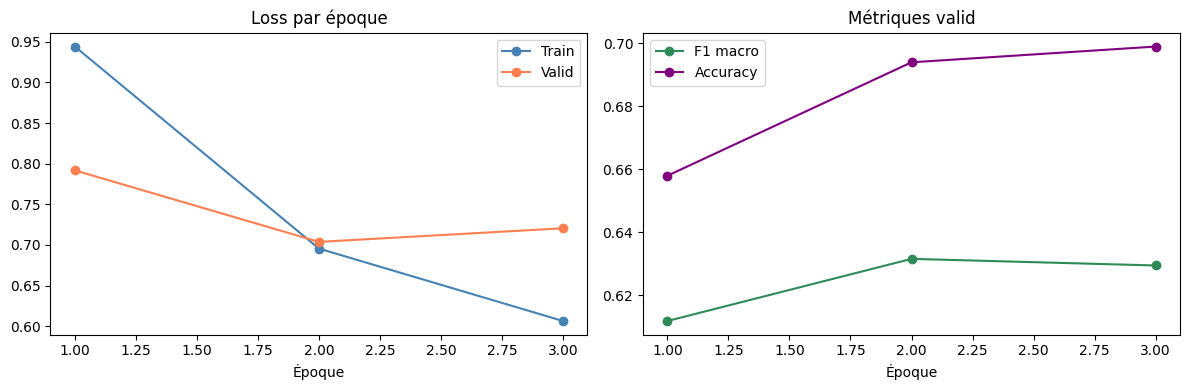

Meilleur F1 : 0.6316


In [ ]:
ep = range(1, EPOCHS + 1)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(ep, history['train_loss'], 'o-', label='Train', color='steelblue')
axes[0].plot(ep, history['valid_loss'], 'o-', label='Valid',  color='coral')
axes[0].set_title('Loss par époque') ; axes[0].set_xlabel('Époque') ; axes[0].legend()

axes[1].plot(ep, history['f1'],  'o-', label='F1 macro', color='seagreen')
axes[1].plot(ep, history['acc'], 'o-', label='Accuracy', color='purple')
axes[1].set_title('Métriques valid') ; axes[1].set_xlabel('Époque') ; axes[1].legend()

plt.tight_layout() ; plt.show()
print(f'Meilleur F1 : {best_f1:.4f}')

## 9. Évaluation finale — Meilleur modèle

Chargement du meilleur checkpoint et évaluation sur valid + test.

In [ ]:

# ── Chargement du meilleur checkpoint ────────────────────────────────────────
# On charge le checkpoint sauvegardé pendant l'entraînement (époque avec le meilleur F1 valid).
# map_location=device : s'assure que les poids sont chargés sur le bon device
# (utile si on charge un modèle entraîné sur GPU sur une machine sans GPU)
model.load_state_dict(torch.load(SAVE_PATH, map_location=device))

# ── Évaluation sur valid ET test ──────────────────────────────────────────────
preds_v, labels_v, _ = evaluate(model, valid_loader)
preds_t, labels_t, _ = evaluate(model, test_loader)
# Le jeu de TEST n'est utilisé qu'UNE SEULE FOIS ici, à la toute fin.
# On ne l'a jamais regardé pendant le développement → évaluation honnête.

acc_v = accuracy_score(labels_v, preds_v) ; f1_v = f1_score(labels_v, preds_v, average='macro')
acc_t = accuracy_score(labels_t, preds_t) ; f1_t = f1_score(labels_t, preds_t, average='macro')

print('=== VALIDATION ===')
print(f'Accuracy : {acc_v:.4f} ({acc_v*100:.2f}%) | F1 macro : {f1_v:.4f}')
print(classification_report(labels_v, preds_v, target_names=['1★','2★','3★','4★','5★']))
# Les labels_v et preds_v sont en base 0 (0-4).
# classification_report affiche les stats par classe — observer particulièrement :
#   - recall de 3★ : souvent le plus faible (avis ambigus difficiles à classer)
#   - f1 de 5★ : le plus élevé (classe majoritaire, vocabulaire distinctif)

print('=== TEST ===')
print(f'Accuracy : {acc_t:.4f} ({acc_t*100:.2f}%) | F1 macro : {f1_t:.4f}')
print(classification_report(labels_t, preds_t, target_names=['1★','2★','3★','4★','5★']))


## 10. Matrice de confusion

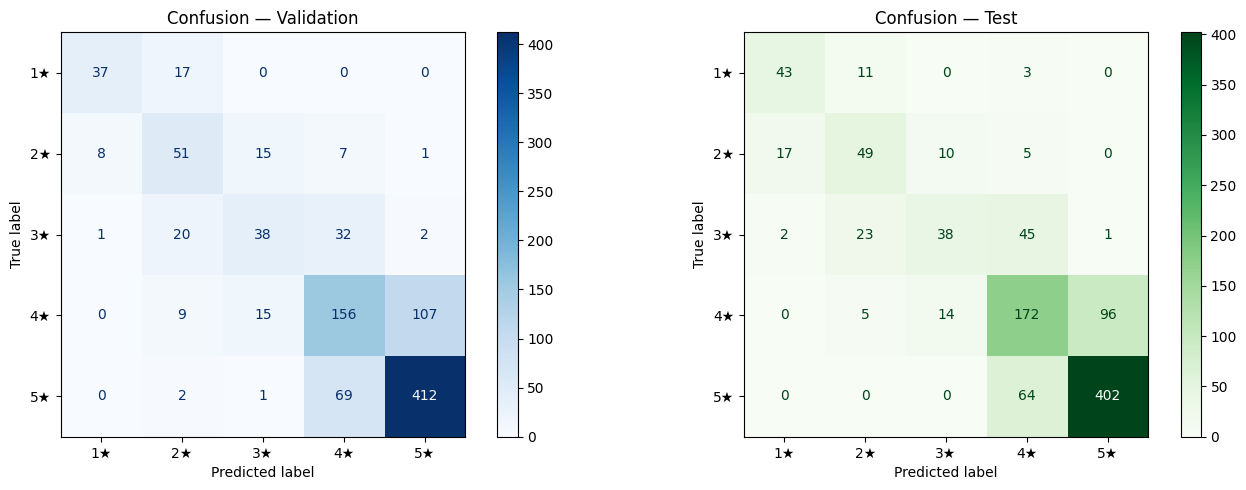

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, p, l, title, cmap in [
    (axes[0], preds_v, labels_v, 'Validation', 'Blues'),
    (axes[1], preds_t, labels_t, 'Test',       'Greens')
]:
    ConfusionMatrixDisplay(confusion_matrix(l, p), display_labels=['1★','2★','3★','4★','5★']).plot(cmap=cmap, ax=ax)
    ax.set_title(f'Confusion — {title}')
plt.tight_layout() ; plt.show()

## 11. Comparaison — Toutes les approches

                       Modèle  Acc valid (%)  F1 macro valid F1 macro test
              TF-IDF + LogReg           63.9           0.516         0.493
           TF-IDF + LinearSVC           60.4           0.489             —
SentenceTransformers + LogReg           63.1           0.510         0.566
            RoBERTa fine-tuné           69.4           0.632         0.635


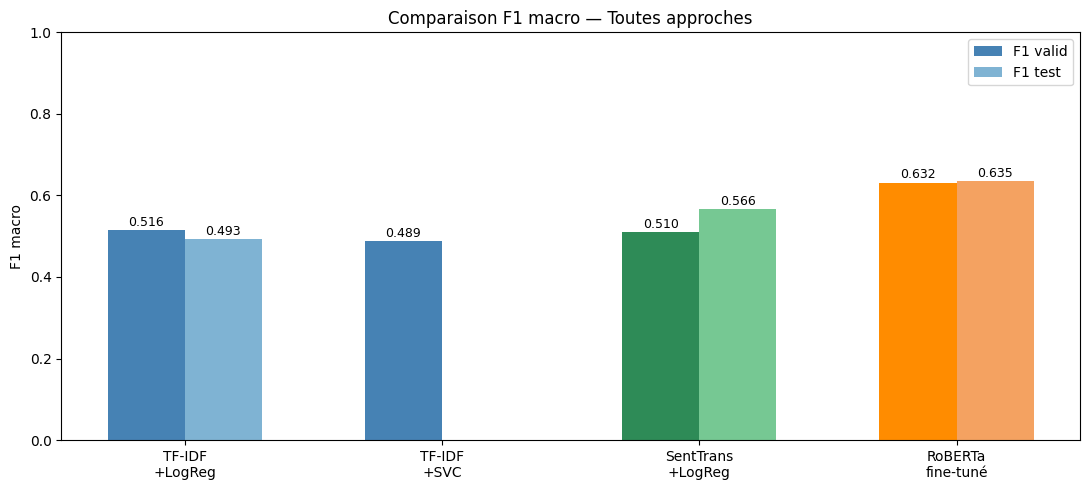

In [ ]:
results = pd.DataFrame({
    'Modèle'         : ['TF-IDF + LogReg', 'TF-IDF + LinearSVC', 'SentenceTransformers + LogReg', 'RoBERTa fine-tuné'],
    'Acc valid (%)'  : [63.9,  60.4,  63.1,  round(acc_v*100, 1)],
    'F1 macro valid' : [0.516, 0.489, 0.510, round(f1_v, 3)],
    'F1 macro test'  : [0.493, '—',   0.566, round(f1_t, 3)],
})
print(results.to_string(index=False))

# Graphique
labels_plot = ['TF-IDF\n+LogReg', 'TF-IDF\n+SVC', 'SentTrans\n+LogReg', 'RoBERTa\nfine-tuné']
f1v = [0.516, 0.489, 0.510, f1_v]
f1t = [0.493, 0,     0.566, f1_t]
x   = np.arange(len(labels_plot)) ; w = 0.3

fig, ax = plt.subplots(figsize=(11, 5))
b1 = ax.bar(x - w/2, f1v, w, label='F1 valid', color=['steelblue','steelblue','seagreen','darkorange'])
b2 = ax.bar(x + w/2, f1t, w, label='F1 test',  color=['#7fb3d3','#7fb3d3','#76c893','#f4a261'])
ax.set_xticks(x) ; ax.set_xticklabels(labels_plot)
ax.set_ylim(0, 1) ; ax.set_ylabel('F1 macro') ; ax.legend()
ax.set_title('Comparaison F1 macro — Toutes approches')
for bar, val in zip(list(b1)+list(b2), f1v+f1t):
    if val > 0:
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.01, f'{val:.3f}', ha='center', fontsize=9)
plt.tight_layout() ; plt.show()

## 12. Analyse des erreurs

Examen des cas mal classés sur le jeu de validation.

Erreurs : 306 / 1000 (30.6%)
Répartition par écart :
ecart
1    283
2     20
3      3
Name: count, dtype: int64


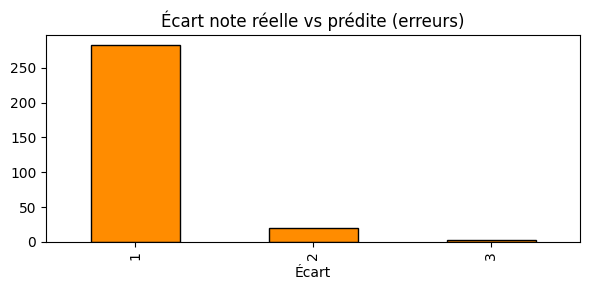


=== 5 exemples mal classés ===

Réel 4★ → Prédit 5★ (écart 1)
animation team impressed animation team resort, special thank pablo jesus wassiel,  ...
----------------------------------------------------------------------

Réel 4★ → Prédit 3★ (écart 1)
married majestic stayed sept. 9-16 majestic travelled excellence punta cana.beach soft white sand gorgeous clear blue water warm gentle waves swimming okay snorkelling, no difficulty finding beach chair, no towel games, beach waiter came hour drinks ...
----------------------------------------------------------------------

Réel 4★ → Prédit 5★ (écart 1)
love animation team, just returned week majestic daughter niece, blast really enjoyed vacation, lucky miss action hurricanes time just right, want thank animation team especially walter tennis pro pleasure hitting mornings, gave great tennis match af...
----------------------------------------------------------------------

Réel 3★ → Prédit 4★ (écart 1)
great resort mediocre food arrival 

In [ ]:
valid_df2 = valid_df.copy()
valid_df2['pred'] = preds_v + 1  # Reconvertir 0-4 → 1-5
errors = valid_df2[valid_df2['Rating'] != valid_df2['pred']].copy()
errors['ecart'] = (errors['Rating'] - errors['pred']).abs()

print(f'Erreurs : {len(errors)} / {len(valid_df2)} ({len(errors)/len(valid_df2)*100:.1f}%)')
print('Répartition par écart :')
print(errors['ecart'].value_counts().sort_index())

errors['ecart'].value_counts().sort_index().plot(
    kind='bar', color='darkorange', edgecolor='black', figsize=(6,3)
)
plt.title('Écart note réelle vs prédite (erreurs)') ; plt.xlabel('Écart') ; plt.tight_layout() ; plt.show()

print('\n=== 5 exemples mal classés ===')
for _, row in errors.head(5).iterrows():
    print(f'\nRéel {row["Rating"]}★ → Prédit {row["pred"]}★ (écart {row["ecart"]})')
    print(str(row['Review'])[:250] + '...')
    print('-' * 70)

## 13. Sauvegarde des prédictions et téléchargement

Les prédictions sont sauvegardées en CSV et téléchargeables depuis Colab.

In [ ]:
# Sauvegarde CSV
pd.DataFrame({
    'Review'        : test_df['Review'],
    'Rating_reel'   : labels_t + 1,
    'Rating_predit' : preds_t  + 1,
}).to_csv('predictions_roberta.csv', index=False)

# Télécharger le CSV et le modèle depuis Colab
from google.colab import files
files.download('predictions_roberta.csv')
files.download('best_roberta.pt')  # Optionnel : télécharger le modèle entraîné

print('=== RÉSUMÉ FINAL ===')
print(f'Modèle           : roberta-base fine-tuné ({EPOCHS} époques)')
print(f'Valid Accuracy   : {acc_v:.4f} ({acc_v*100:.2f}%)')
print(f'Valid F1 macro   : {f1_v:.4f}')
print(f'Test  Accuracy   : {acc_t:.4f} ({acc_t*100:.2f}%)')
print(f'Test  F1 macro   : {f1_t:.4f}')
print(f'Gain vs TF-IDF   : F1 {f1_t - 0.493:+.3f}')
print(f'Gain vs SentTrans: F1 {f1_t - 0.566:+.3f}')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

=== RÉSUMÉ FINAL ===
Modèle           : roberta-base fine-tuné (3 époques)
Valid Accuracy   : 0.6940 (69.40%)
Valid F1 macro   : 0.6316
Test  Accuracy   : 0.7040 (70.40%)
Test  F1 macro   : 0.6355
Gain vs TF-IDF   : F1 +0.142
Gain vs SentTrans: F1 +0.069
